**A BAGGING TECHNIQUE BASED ON DECISION TRESS ALGORITHUM**

- CAN BE APPLIED TO ANY PROBLEM
- WORKS ON CLASSIFICATION AS WELL AS REGRESSION
- DONOT NEED MUCH HYPER-PARAMETER TUNNING

# BOOTSTRAPPING
**SAMPLING IS DONE BY TWO WAYS EITHER WITH OR WOIHOUT REPLACEMENT MEANS DUPLICATION CAN BE POSSIBLE IN WITH REPLACEMENT CASE.TYPES INCLUDE:**
- ROWS SAMPLING
- FEATURE SAMPLING
- COMBINATION SAMPLING

# AGGREGATION
FOR PREDICTION WE SIMPLY COUNT ON THE DEMOCRACY RULE I.E
- **IN CLASSIFICATION SETUP => MAJORITY COUNT**
- **IN REGRESSION SETUP     =>          MEAN VALUE**



---



---



---



In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.499881,-3.048204,-2.627349,-2.176976,2.649350,0
1,-1.195240,-2.269029,1.709352,1.740826,1.547275,0
2,-1.457961,-1.197607,-1.004709,-0.554462,1.062569,0
3,-0.021164,-2.744866,-2.847374,-2.432189,2.471743,0
4,-3.093281,0.381558,-1.124985,-0.032182,-0.092977,0


In [4]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [5]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [6]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

# function for row sampling


In [7]:
df1 = sample_rows(df,0.1)
df2 = sample_rows(df,0.1)
df3 = sample_rows(df,0.1)

In [8]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [9]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

[Text(0.4, 0.8333333333333334, 'x[0] <= -0.48\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.6, 0.5, 'x[2] <= -2.214\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]')]

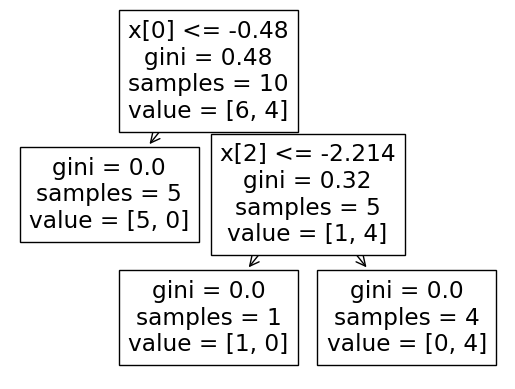

In [10]:
from sklearn.tree import plot_tree
plot_tree(clf1)

[Text(0.4, 0.8333333333333334, 'x[0] <= 0.674\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.6, 0.5, 'x[0] <= 1.382\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]')]

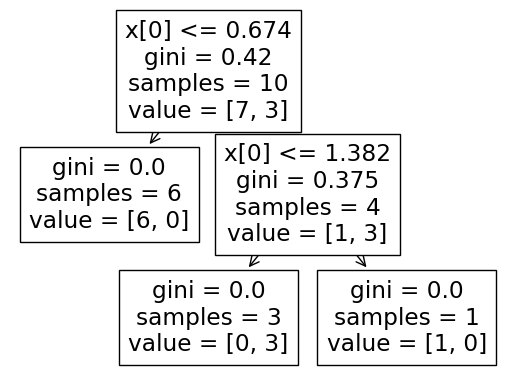

In [11]:
plot_tree(clf2)

[Text(0.4, 0.8333333333333334, 'x[0] <= 0.294\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.6, 0.5, 'x[0] <= 1.259\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]')]

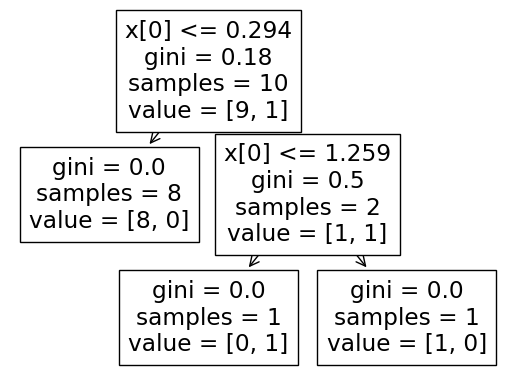

In [12]:
plot_tree(clf3)

In [14]:
clf1.predict(np.array([-0.499881,	-3.048204,	-2.627349,	-2.176976,	2.649350]).reshape(1,5))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [15]:
clf2.predict(np.array([-0.499881,	-3.048204,	-2.627349,	-2.176976,	2.649350]).reshape(1,5))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [16]:
clf3.predict(np.array([-0.499881,	-3.048204,	-2.627349,	-2.176976,	2.649350]).reshape(1,5))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

**BASED ON THIS RESULT OUTPUT WOULD BE ZERO**



---



---



**SAME CAN BE DONE WITH FEATURE SAMPLING AND COMBINED SAMPLING**